Используем предобученную модель

In [1]:
from ultralytics import YOLO
import cv2
import torch
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
model = YOLO("yolo12s.pt")

WARNING torchvision==0.20 is incompatible with torch==2.6.
Run 'pip install torchvision==0.21' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation


In [2]:
# Проверка на работоспособность CUDA
print(torch.__version__)  # Версия PyTorch
print(torch.cuda.is_available())  # Доступна ли CUDA?
print(torch.version.cuda)  # Версия CUDA, с которой собран PyTorch

2.6.0.dev20241112+cu121
True
12.1


Делаем предсказание по изображению


0: 448x640 3 cars, 1 truck, 1 stop sign, 51.1ms
Speed: 4.5ms preprocess, 51.1ms inference, 79.9ms postprocess per image at shape (1, 3, 448, 640)


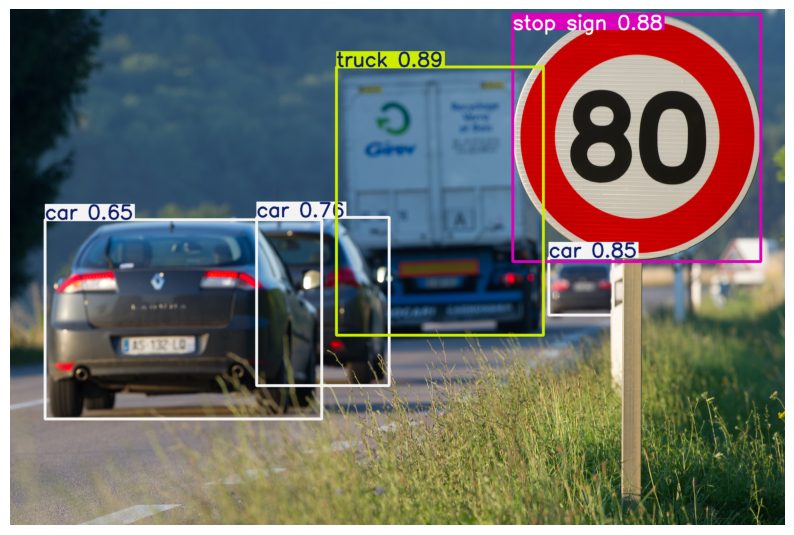

In [ ]:
def predict_and_show(image_path, model_path="yolov8n.pt"):
    """
    Функция для предсказания объектов на изображении с помощью YOLO и визуализации результатов в Jupyter Notebook
    
    Аргументы:
        image_path (str): Путь к файлу изображения
        model_path (str): Путь к файлу весов модели YOLO (по умолчанию "yolov8n.pt")
    """
    # Загрузка модели (принудительно на CPU, если CUDA не работает)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = YOLO(model_path).to(device)
    
    # Чтение изображения
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: не удалось загрузить изображение по пути {image_path}")
        return
    
    # Предсказание
    results = model.predict(image)
    
    # Визуализация результатов
    annotated_image = results[0].plot()
    
    # Конвертация из BGR (OpenCV) в RGB (matplotlib)
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    
    # Вывод изображения с помощью matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(annotated_image_rgb)
    plt.axis('off')  # Скрыть оси
    plt.show()
    
predict_and_show("images\lxjh2x6rv0finbsjv17qmu7hi1hsr1jv.jpeg")

Выводим детальную информацию по изображению

In [ ]:
def predict_and_describe(image_path, model_path="yolov8n.pt", conf_threshold=0.5):
    """
    Функция для предсказания объектов на изображении с помощью YOLO и вывода детальной информации в консоль
    
    Аргументы:
        image_path (str): Путь к файлу изображения
        model_path (str): Путь к файлу весов модели YOLO
        conf_threshold (float): Порог уверенности для отображения объектов (по умолчанию 0.5)
    """
    # Загрузка модели
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = YOLO(model_path).to(device)
    
    # Чтение изображения
    image = cv2.imread(image_path)
    if image is None:
        print(f"Ошибка: не удалось загрузить изображение по пути {image_path}")
        return
    
    # Предсказание
    results = model.predict(image)
    
    # Получаем первый результат (если изображение одно)
    result = results[0]
    
    # Выводим заголовок
    print("\nРезультаты обнаружения объектов:")
    print("-" * 60)
    
    # Перебираем все обнаруженные объекты
    for i, box in enumerate(result.boxes):
        # Получаем класс объекта
        class_id = int(box.cls)
        class_name = result.names[class_id]
        
        # Получаем координаты bounding box (xyxy формат)
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        
        # Получаем уверенность предсказания
        confidence = float(box.conf)
        
        # Пропускаем объекты с низкой уверенностью
        if confidence < conf_threshold:
            continue
        
        # Выводим информацию об объекте
        print(f"Объект #{i+1}:")
        print(f"  Класс: {class_name} ({class_id})")
        print(f"  Координаты: [({x1:.2f}, {y1:.2f}), ({x2:.2f}, {y2:.2f})]")
        print(f"  Уверенность: {confidence:.4f}")
        print("-" * 60)
    

predict_and_describe("images\lxjh2x6rv0finbsjv17qmu7hi1hsr1jv.jpeg")


0: 448x640 3 cars, 1 truck, 1 stop sign, 11.0ms
Speed: 1.6ms preprocess, 11.0ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)

Результаты обнаружения объектов:
------------------------------------------------------------
Объект #1:
  Класс: truck (7)
  Координаты: [(842.99, 149.48), (1376.70, 841.30)]
  Уверенность: 0.8899
------------------------------------------------------------
Объект #2:
  Класс: stop sign (11)
  Координаты: [(1297.22, 13.75), (1937.06, 651.76)]
  Уверенность: 0.8796
------------------------------------------------------------
Объект #3:
  Класс: car (2)
  Координаты: [(1390.80, 641.28), (1556.68, 789.70)]
  Уверенность: 0.8484
------------------------------------------------------------
Объект #4:
  Класс: car (2)
  Координаты: [(636.66, 537.77), (978.84, 971.19)]
  Уверенность: 0.7566
------------------------------------------------------------
Объект #5:
  Класс: car (2)
  Координаты: [(90.54, 543.06), (804.37, 1057.46)]
  Уверенность: 0.64

Добавил свои изображения к исходному датасету 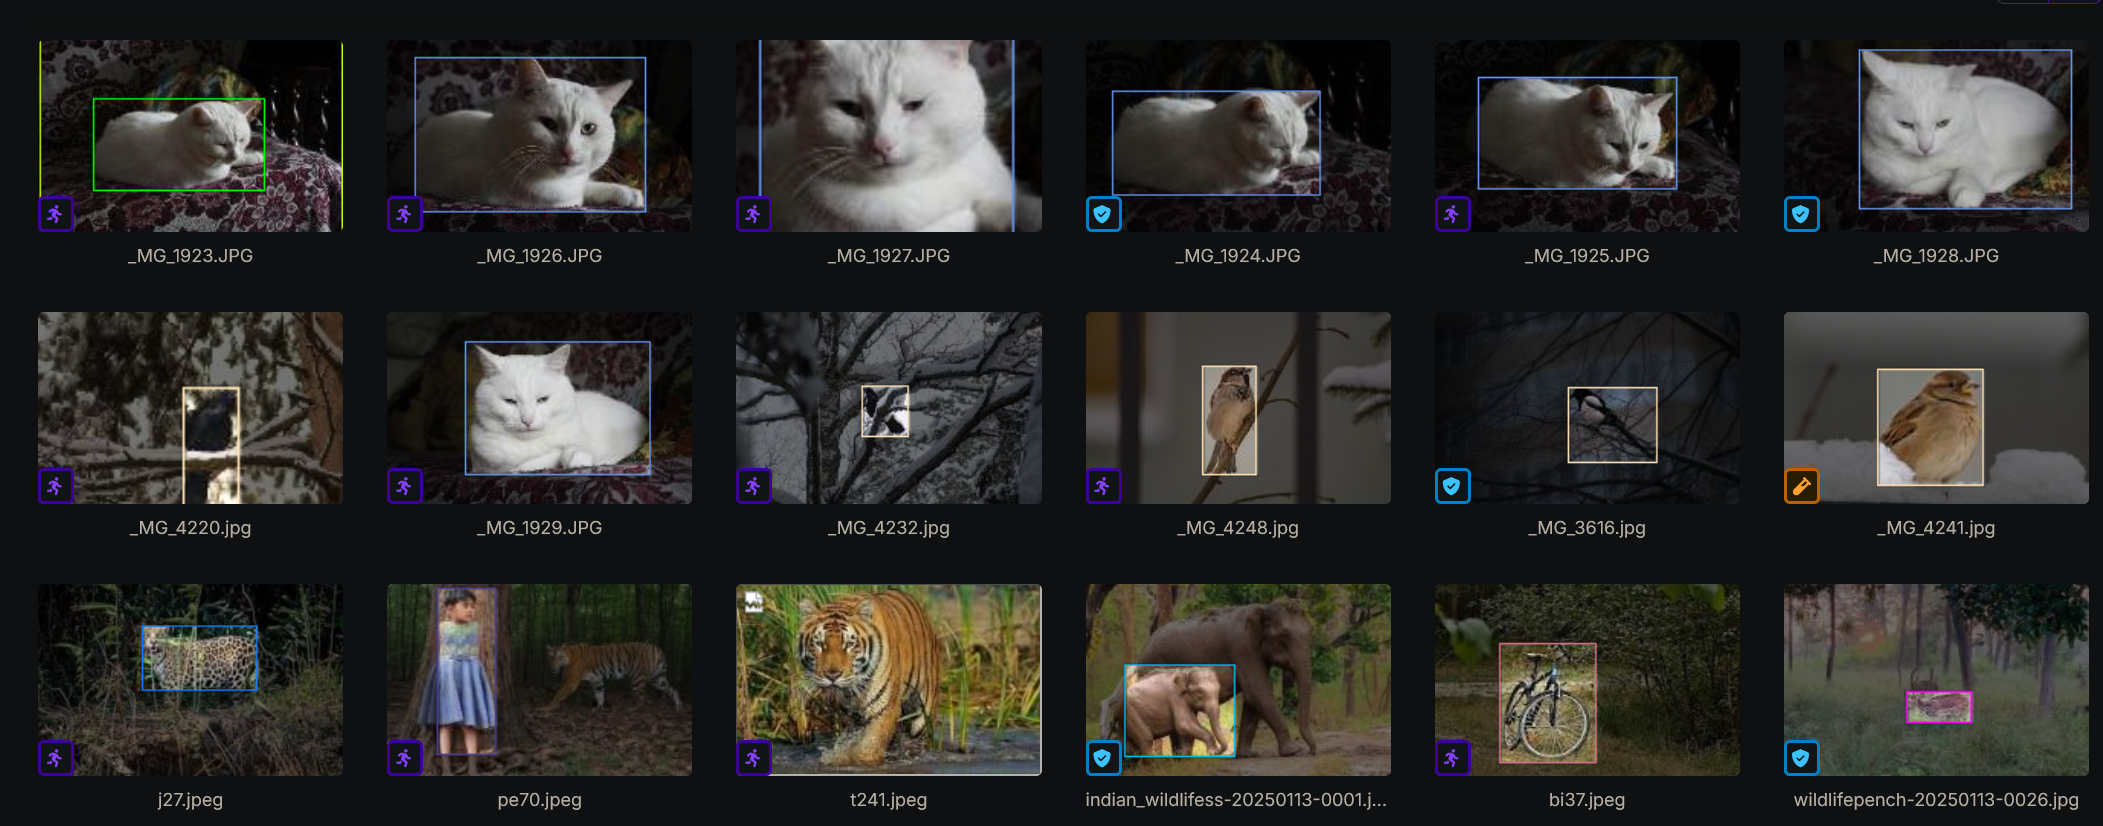  
Сделал следующие аугментации  
 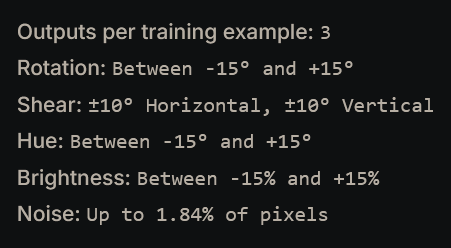

In [ ]:
# Импорты и настройки путей
import os
import glob
from ultralytics import YOLO

# Путь к папке с данными
DATA_DIR = r"C:\\Users\\leous\\.vscode\\computer_vision\\Практика 4\\object-detection-1"
DATA_YAML = os.path.join(DATA_DIR, "data.yaml")

# Директория для чекпоинтов
CKPT_DIR = os.path.join(os.getcwd(), "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)

# Ищем последний чекпоинт для продолжения
all_ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, "*.pt")), key=os.path.getctime)
resume_ckpt = all_ckpts[-1] if all_ckpts else None
print("Resume from:", resume_ckpt)

# Создаём кастомный callback
def custom_batch_callback(trainer):
    if hasattr(trainer, 'batch_i') and trainer.batch_i is not None:
        batch_idx = trainer.batch_i + trainer.epoch * len(trainer.train_loader)
        if batch_idx > 0 and batch_idx % 5 == 0:
            fname = f"ckpt_step{batch_idx}.pt"
            path = os.path.join(CKPT_DIR, fname)
            print(f"Saving checkpoint: {path}")
            trainer.model.save(path)
            ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, "*.pt")), key=os.path.getctime)
            if len(ckpts) > 5:
                for obsolete in ckpts[:-5]:
                    os.remove(obsolete)

model.add_callback('on_train_batch_end', custom_batch_callback)

model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=8,  # уменьшаем batch size
    workers=2,  # уменьшаем число workers
    resume=resume_ckpt
)

Resume from: None


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000016631B4AE60>
Traceback (most recent call last):
  File "c:\Users\leous\.vscode\computer_vision\.venv\lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "c:\Users\leous\.vscode\computer_vision\.venv\lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


Ultralytics 8.3.122  Python-3.10.11 torch-2.6.0.dev20241112+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolo12s.pt, data=C:\\Users\\leous\\.vscode\\computer_vision\\ 4\\object-detection-1\data.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=2, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=None, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=F

train: Scanning C:\Users\leous\.vscode\computer_vision\Практика 4\object-detection-1\train\labels.cache... 4323 images, 1071 backgrounds, 0 corrupt: 100%|██████████| 4323/4323 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.10.0 ms, read: 159.759.0 MB/s, size: 67.5 KB)


...

      50/50       3.4G     0.5766      0.307      1.119          2        640: 100%|██████████| 541/541 [05:46<00:00,  1.56it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 23/23 [00:23<00:00,  1.01s/it]

                   all        363        371      0.426      0.405      0.417      0.269



50 epochs completed in 4.481 hours.
Optimizer stripped from c:\Users\leous\.vscode\computer_vision\runs\detect\train5\weights\last.pt, 18.9MB
Optimizer stripped from c:\Users\leous\.vscode\computer_vision\runs\detect\train5\weights\best.pt, 18.9MB

Validating c:\Users\leous\.vscode\computer_vision\runs\detect\train5\weights\best.pt...
Ultralytics 8.3.122  Python-3.10.11 torch-2.6.0.dev20241112+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLOv12s summary (fused): 159 layers, 9,239,781 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 23/23 [00:09<00:00,  2.45it/s]


                   all        363        371      0.456      0.451      0.494      0.316
                  bear         12         14        0.3        0.5      0.389        0.2
                  bird          2          2          0          0    0.00752    0.00301
                   cat          2          2      0.565          1      0.995      0.796
                cattle          4          4      0.185          1      0.745      0.536
               cheetah          2          2        0.9          1      0.995      0.796
                  deer         50         64          1          0      0.228       0.11
                   dog          3          4     0.0472       0.75      0.351      0.256
              elephant         39         43      0.787      0.087      0.394      0.207
                   fox         53         55      0.946      0.317      0.734      0.434
                  goat          1          1          0          0     0.0133     0.0106
                 hors

In [11]:
model.save("yolo_model.pt")


0: 448x640 1 bird, 11.7ms
Speed: 2.9ms preprocess, 11.7ms inference, 2.6ms postprocess per image at shape (1, 3, 448, 640)


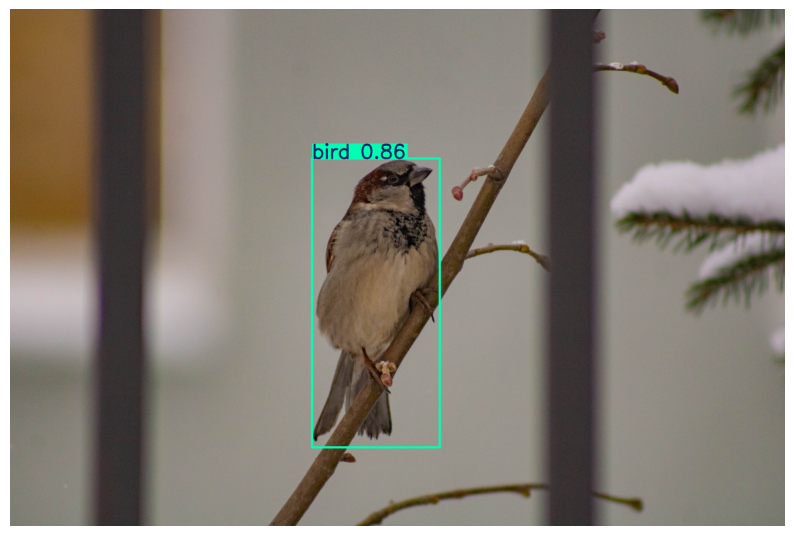


0: 640x448 2 birds, 15.3ms
Speed: 5.1ms preprocess, 15.3ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 448)


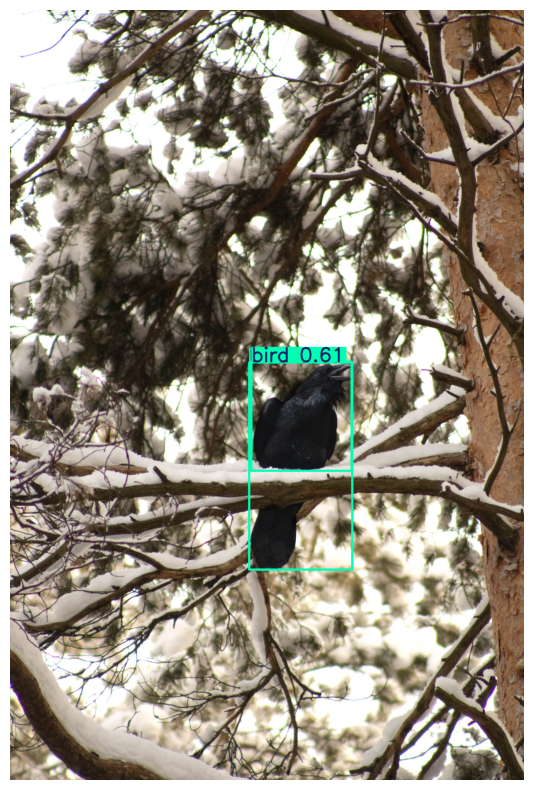


0: 448x640 1 cat, 1 bed, 10.9ms
Speed: 2.3ms preprocess, 10.9ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)


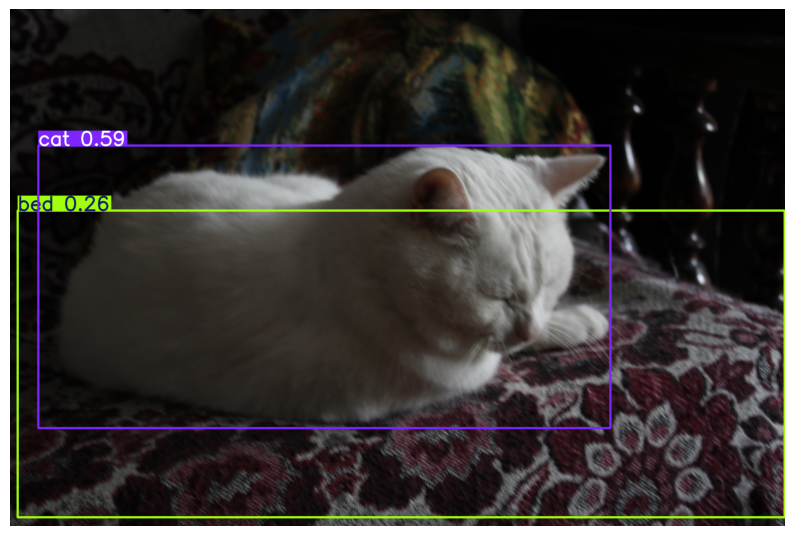


0: 448x640 1 cat, 1 couch, 14.0ms
Speed: 2.0ms preprocess, 14.0ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)


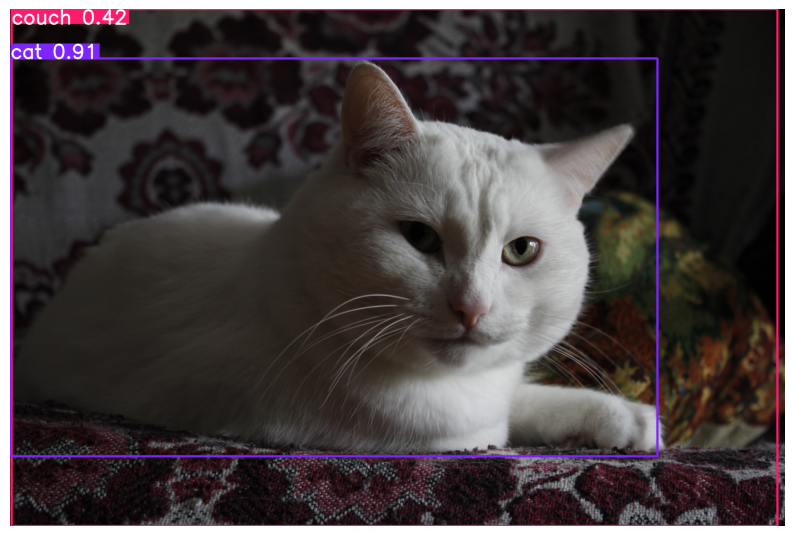


0: 448x640 1 cat, 1 bed, 10.6ms
Speed: 2.2ms preprocess, 10.6ms inference, 2.4ms postprocess per image at shape (1, 3, 448, 640)


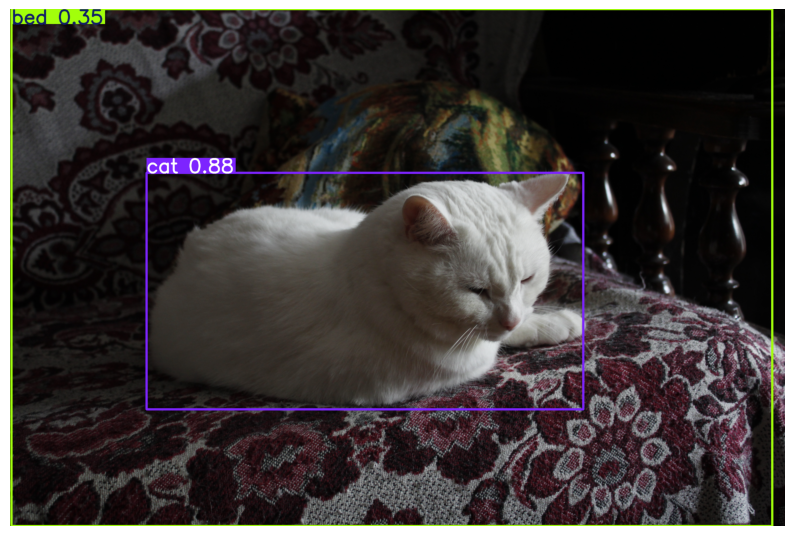

In [31]:
import random

def get_random_file_path(folder_path):
    # Получаем список всех файлов в папке
    files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    if not files:
        raise FileNotFoundError(f"В папке {folder_path} нет файлов.")
    # Выбираем случайный файл
    random_file = random.choice(files)
    # Возвращаем полный путь
    return os.path.join(folder_path, random_file)

# predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/object-detection-1/valid/images"))
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/images"))
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/images"))
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/images"))
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/images"))
predict_and_show(get_random_file_path("C:/Users/leous/.vscode/computer_vision/Практика 4/images"))